# Lista 4 - Tomasz Jarmoc & Mateusz Izdebski

In [15]:
import sympy as sp
from sympy import symbols, diff, solve, sqrt, Matrix, simplify
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sp.init_printing(use_unicode=True)
x, y, z, l = symbols('x y z l')

## Zadanie 1 

In [ ]:
# I SPOSÓB - METODA MNOŻNIKÓW LAGRANGA

f = 6 - sqrt(3*x**2 + 3*y**2)
g = y - x - 1

L = f - l*g
dLdl = diff(L, l)
dLdx = diff(L, x)
dLdy = diff(L, y)

print("f(x,y) = ")
display(f)
print("g(x,y) = ")
display(g)
print()

critical_points_raw = solve([dLdl, dLdx, dLdy], [x, y, l], dict=True)
critical_points = critical_points_raw if isinstance(critical_points_raw, list) else [critical_points_raw]

for i, cp in enumerate(critical_points):
    if isinstance(cp, dict):
        x0 = cp[x]
        y0 = cp[y]
        l0 = cp[l]
        
        dg_dx = diff(g, x)
        dg_dy = diff(g, y)
        dL_dxx = diff(L, x, 2)
        dL_dyy = diff(L, y, 2)
        dL_dxy = diff(L, x, y)
        
        H = Matrix([[0, dg_dx, dg_dy], [dg_dx, dL_dxx, dL_dxy], [dg_dy, dL_dxy, dL_dyy]])
        H_vals = H.subs({x: x0, y: y0})
        delta2 = H_vals.det()
        
        print(f"Punkt: xo = {x0}, yo = {y0}, lambda_o = {l0}")
        print(f"\nMacierz:")
        display(H_vals)
        print(f"\n Wyznacznik macierzy =")
        display(delta2)
        print(f"Typ: {'MAKSIMUM' if delta2 > 0 else 'MINIMUM' if delta2 < 0 else '??'}\n")
        print("Wartość funkcji:")
        display(f.subs({x: x0, y: y0}))
        print()
        
        global_cp_list = [(x0, y0)]

f(x,y) = 


g(x,y) = 



Punkt: xo = -1/2, yo = 1/2, lambda_o = -sqrt(6)/2

Macierz:


⎡0    -1    1  ⎤
⎢              ⎥
⎢    -√6   -√6 ⎥
⎢-1  ────  ────⎥
⎢     2     2  ⎥
⎢              ⎥
⎢    -√6   -√6 ⎥
⎢1   ────  ────⎥
⎣     2     2  ⎦


 Wyznacznik macierzy =


Typ: MAKSIMUM

Wartość funkcji:


Funkcja zredukowana (po podstawieniu y = x+1):
f(x) =


Punkt ekstremum:
  x =


  y =


  f =


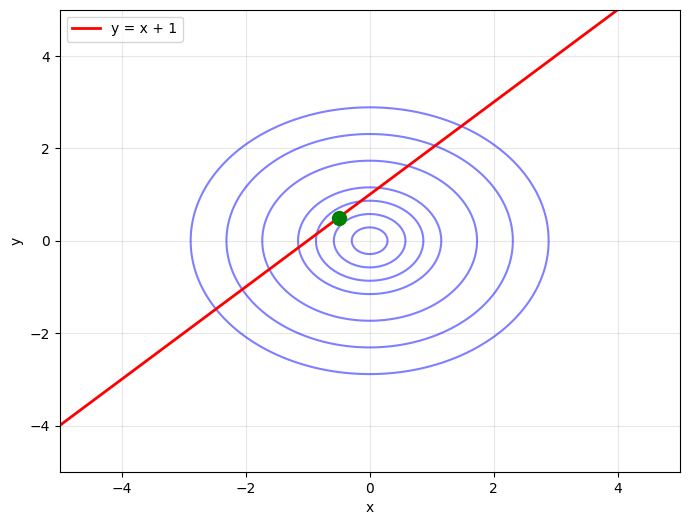

In [23]:
# II SPOSÓB - METODA GRAFICZNA

expr = 6*x**2 + 6*x + 3
f_reduced = 6 - sqrt(expr)
df_reduced = diff(f_reduced, x)

print("Funkcja zredukowana (po podstawieniu y = x+1):")
print("f(x) =")
display(f_reduced)

critical_x = solve(df_reduced, x)

fig, ax = plt.subplots(figsize=(8, 6))

x_vals = np.linspace(-5, 5, 300)
y_vals = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 6 - np.sqrt(3*X**2 + 3*Y**2)

ax.contour(X, Y, Z, levels=[1, 2, 3, 4, 4.5, 5, 5.5, 6], colors='blue', alpha=0.5)
x_line = np.linspace(-5, 4, 100)
y_line = x_line + 1
ax.plot(x_line, y_line, 'r-', linewidth=2, label='y = x + 1')

for x_crit in critical_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        f_crit = f_reduced.subs(x, x_crit)
        ax.plot(float(x_crit.evalf()), float(y_crit.evalf()), 'go', markersize=10)
        print("Punkt ekstremum:")
        print(f"  x =")
        display(x_crit)
        print(f"  y =")
        display(y_crit)
        print(f"  f =")
        display(f_crit)
        print()

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [24]:
print("SPROWADZENIE DO EKSTREMUM LOKALNEGO\n")

f_single = 6 - sqrt(6*x**2 + 6*x + 3)
df_dx = diff(f_single, x)
d2f_dx2 = diff(df_dx, x)

print("Funkcja jednej zmiennej:")
print("f(x) =")
display(f_single)
print()

critical_points_x = solve(df_dx, x)
max_point = None
max_value = -float('inf')

for x_crit in critical_points_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        z_crit = f_single.subs(x, x_crit)
        d2f_val = d2f_dx2.subs(x, x_crit)
        
        ekstremum_type = "MAX" if d2f_val < 0 else "MIN" if d2f_val > 0 else "?"
        z_val = float(z_crit.evalf())
        
        print(f"xo =")
        display(x_crit)
        print(f"yo =")
        display(y_crit)
        print(f"f''(xo) =")
        display(d2f_val)
        print(f"→ {ekstremum_type}\n")
        print(f"f(xo, yo) =")
        display(z_crit)
        print()
        
        if ekstremum_type == "MAX" and z_val > max_value:
            max_value = z_val
            max_point = (x_crit, y_crit, z_crit)

SPROWADZENIE DO EKSTREMUM LOKALNEGO

Funkcja jednej zmiennej:
f(x) =



xo =


yo =


f''(xo) =


→ MAX

f(xo, yo) =
